In [63]:
import pandas as pd

df = pd.read_csv('../data/Funnel_Analysis_Data.csv')

df.head()

,User ID,Session ID,Event Time,Event,Device,Region,Channel,Product Category,Revenue,Bonus Flag
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21409 entries, 0 to 21408
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User ID           21409 non-null  str    
 1   Session ID        21409 non-null  str    
 2   Event Time        21409 non-null  str    
 3   Event             21409 non-null  str    
 4   Device            21409 non-null  str    
 5   Region            21409 non-null  str    
 6   Channel           21409 non-null  str    
 7   Product Category  21409 non-null  str    
 8   Revenue           21409 non-null  float64
 9   Bonus Flag        21409 non-null  str    
dtypes: float64(1), str(9)
memory usage: 1.6 MB


In [65]:
df.shape

(21409, 10)

In [66]:
df.isnull().sum()

User ID             0
Session ID          0
Event Time          0
Event               0
Device              0
Region              0
Channel             0
Product Category    0
Revenue             0
Bonus Flag          0
dtype: int64

In [67]:
df.columns

Index(['User ID', 'Session ID', 'Event Time', 'Event', 'Device', 'Region',
       'Channel', 'Product Category', 'Revenue', 'Bonus Flag'],
      dtype='str')

In [68]:
df['Event'].unique()

<StringArray>
['Browse', 'Add to Cart', 'Checkout', 'Purchase']
Length: 4, dtype: str

In [69]:
df['Device'].unique()

<StringArray>
['Tablet', 'Desktop', 'Mobile']
Length: 3, dtype: str

In [70]:
df['Channel'].unique()

<StringArray>
['Organic', 'Email', 'Google Ads', 'Social Media']
Length: 4, dtype: str

In [71]:
df['Region'].unique()

<StringArray>
['South', 'East', 'West', 'North']
Length: 4, dtype: str

In [72]:
df['Product Category'].unique()

<StringArray>
['Electronics', 'Sports', 'Fashion', 'Beauty', 'Home']
Length: 5, dtype: str

In [73]:
df.groupby('Event')['User ID'].nunique()

Event
Add to Cart     6949
Browse         10000
Checkout        3456
Purchase        1004
Name: User ID, dtype: int64

In [74]:
funnel = df.groupby('Event')['User ID'].nunique().reset_index()

funnel.columns = ['Event', 'Users']

funnel

,Event,Users
0,Add to Cart,6949
1,Browse,10000
2,Checkout,3456
3,Purchase,1004


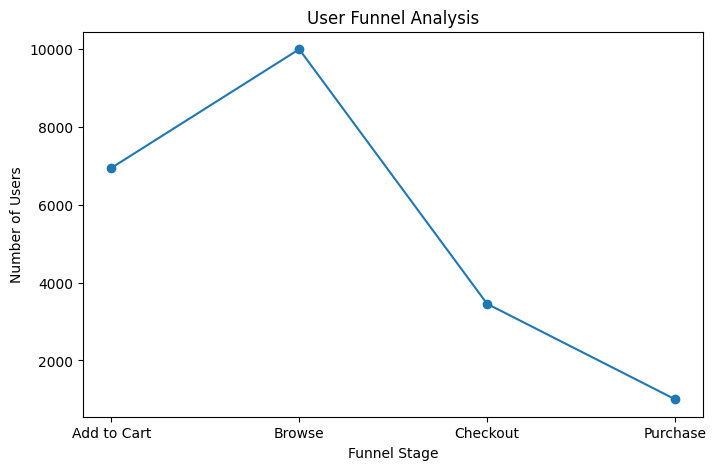

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(funnel['Event'], funnel['Users'], marker='o')

plt.title('User Funnel Analysis')

plt.xlabel('Funnel Stage')

plt.ylabel('Number of Users')

plt.show()

In [76]:
browse_users = funnel[funnel['Event']=='Browse']['Users'].values[0]

purchase_users = funnel[funnel['Event']=='Purchase']['Users'].values[0]

conversion_rate = (purchase_users / browse_users) * 100

print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 10.04%


In [77]:
funnel_order = ['Browse', 'Add to Cart', 'Checkout', 'Purchase']

funnel['Event'] = pd.Categorical(
    funnel['Event'],
    categories=funnel_order,
    ordered=True
)

funnel = funnel.sort_values('Event')

funnel

,Event,Users
1,Browse,10000
0,Add to Cart,6949
2,Checkout,3456
3,Purchase,1004


In [78]:
funnel['Drop_off'] = funnel['Users'].shift(1) - funnel['Users']

funnel

,Event,Users,Drop_off
1,Browse,10000,NaN
0,Add to Cart,6949,3051.0
2,Checkout,3456,3493.0
3,Purchase,1004,2452.0


In [79]:
funnel['Drop_off_%'] = (
    funnel['Drop_off'] / funnel['Users'].shift(1)
) * 100

funnel

,Event,Users,Drop_off,Drop_off_%
1,Browse,10000,NaN,NaN
0,Add to Cart,6949,3051.0,30.510000
2,Checkout,3456,3493.0,50.266225
3,Purchase,1004,2452.0,70.949074


# Funnel Analysis Insights

## Key Findings

- The overall conversion funnel shows a significant decline in users at each stage.
- Around 30.5% of users drop after browsing without adding products to cart.
- The largest drop-off occurs between Checkout and Purchase with nearly 71% user loss.
- This indicates strong purchase friction during the final transaction stage.

## Business Interpretation

- Users are interested in products but hesitate during final purchase completion.
- Possible reasons may include:
  - complicated checkout process
  - payment failures
  - lack of trust signals
  - shipping costs
  - slow website/app performance

## Recommendations

- Simplify checkout flow
- Reduce unnecessary form fields
- Improve payment experience
- Add trust indicators and offers
- Optimize mobile checkout performance

In [80]:
channel_analysis = df.groupby('Channel').agg({
    'User ID': 'nunique',
    'Revenue': 'sum'
}).reset_index()

channel_analysis.columns = ['Channel', 'Users', 'Revenue']

channel_analysis

,Channel,Users,Revenue
0,Email,2515,69126.46
1,Google Ads,2520,73862.32
2,Organic,2528,65973.04
3,Social Media,2437,68361.24


In [81]:
channel_analysis['Revenue_per_User'] = (
    channel_analysis['Revenue'] / channel_analysis['Users']
)

channel_analysis.sort_values(
    by='Revenue_per_User',
    ascending=False
)

,Channel,Users,Revenue,Revenue_per_User
1,Google Ads,2520,73862.32,29.310444
3,Social Media,2437,68361.24,28.051391
0,Email,2515,69126.46,27.485670
2,Organic,2528,65973.04,26.096930


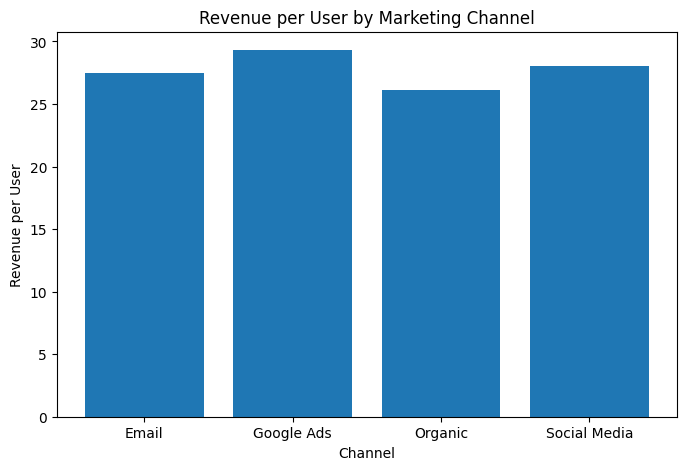

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    channel_analysis['Channel'],
    channel_analysis['Revenue_per_User']
)

plt.xlabel('Channel')
plt.ylabel('Revenue per User')
plt.title('Revenue per User by Marketing Channel')

plt.show()

# Channel Performance Insights

## Key Findings

- Google Ads generates the highest revenue per user among all acquisition channels.
- Organic traffic brings comparatively lower revenue efficiency.
- Email and Social Media channels perform moderately well.

## Business Interpretation

- Paid acquisition users appear to have stronger purchase intent.
- Organic users may be exploring products without strong buying intent.
- Marketing ROI differs significantly across channels.

## Recommendations

- Increase investment in high-performing paid channels
- Improve targeting strategies for organic users
- Retarget low-converting users using email campaigns
- Analyze customer behavior across acquisition sources

In [84]:
device_analysis = df.groupby('Device').agg({
    'User ID': 'nunique',
    'Revenue': 'sum'
}).reset_index()

device_analysis.columns = ['Device', 'Users', 'Revenue']

device_analysis['Revenue_per_User'] = (
    device_analysis['Revenue'] / device_analysis['Users']
)

device_analysis

,Device,Users,Revenue,Revenue_per_User
0,Desktop,3366,98471.83,29.254851
1,Mobile,3263,84231.10,25.814006
2,Tablet,3371,94620.13,28.068861


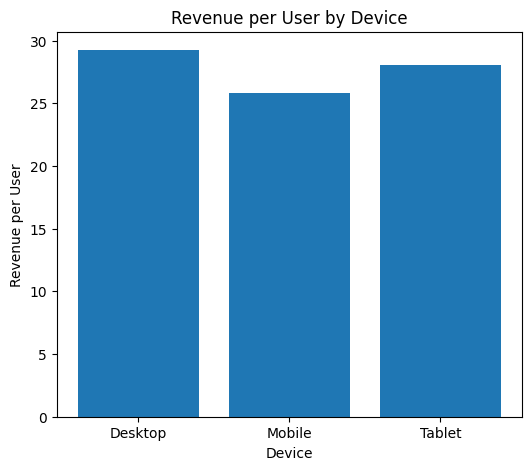

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    device_analysis['Device'],
    device_analysis['Revenue_per_User']
)

plt.xlabel('Device')
plt.ylabel('Revenue per User')
plt.title('Revenue per User by Device')

plt.show()

# Device Performance Insights

## Key Findings

- Desktop users generate the highest revenue per user.
- Mobile users contribute the lowest monetization efficiency.
- Tablet users perform moderately well compared to other devices.

## Business Interpretation

- Mobile users may be facing UX friction during browsing or checkout.
- Desktop users likely experience smoother navigation and purchase flow.
- Lower mobile monetization may indicate:
  - poor mobile optimization
  - slower performance
  - difficult checkout experience
  - payment usability issues

## Recommendations

- Improve mobile user experience and checkout flow
- Optimize mobile page speed and responsiveness
- Reduce friction in mobile payment process
- Conduct A/B testing specifically for mobile users

In [86]:
df['Event Time'] = pd.to_datetime(df['Event Time'])

df['Hour'] = df['Event Time'].dt.hour

df.head()

,User ID,Session ID,Event Time,Event,Device,Region,Channel,Product Category,Revenue,Bonus Flag,Hour
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes,23
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes,23
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes,23
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes,21
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes,21


In [87]:
hourly_activity = df.groupby('Hour').agg({
    'User ID': 'nunique'
}).reset_index()

hourly_activity.columns = ['Hour', 'Active_Users']

hourly_activity

,Hour,Active_Users
0,0,422
1,1,401
2,2,480
3,3,428
4,4,473
5,5,444
6,6,403
7,7,454
8,8,474
9,9,450


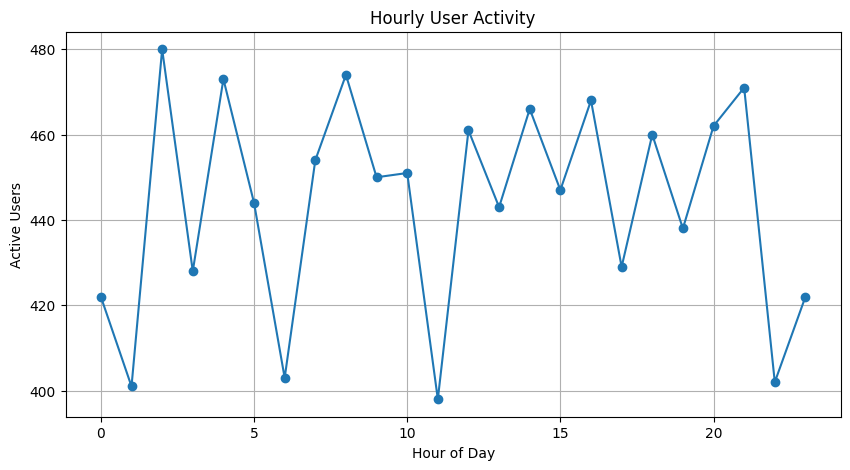

In [88]:
plt.figure(figsize=(10,5))

plt.plot(
    hourly_activity['Hour'],
    hourly_activity['Active_Users'],
    marker='o'
)

plt.xlabel('Hour of Day')
plt.ylabel('Active Users')
plt.title('Hourly User Activity')

plt.grid(True)

plt.show()

In [89]:
region_analysis = df.groupby('Region').agg({
    'Revenue': 'sum',
    'User ID': 'nunique'
}).reset_index()

region_analysis.columns = ['Region', 'Revenue', 'Users']

region_analysis['Revenue_per_User'] = (
    region_analysis['Revenue'] / region_analysis['Users']
)

region_analysis.sort_values(
    by='Revenue',
    ascending=False
)

,Region,Revenue,Users,Revenue_per_User
2,South,77421.45,2543,30.444927
1,North,68645.13,2463,27.870536
0,East,66116.01,2548,25.948199
3,West,65140.47,2446,26.631427


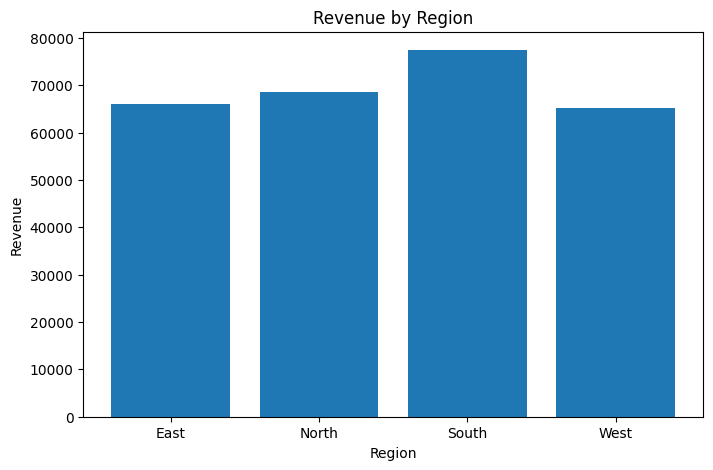

In [90]:
plt.figure(figsize=(8,5))

plt.bar(
    region_analysis['Region'],
    region_analysis['Revenue']
)

plt.xlabel('Region')
plt.ylabel('Revenue')
plt.title('Revenue by Region')

plt.show()

In [91]:
user_revenue = df.groupby('User ID')['Revenue'].sum().reset_index()

user_revenue.columns = ['User_ID', 'Total_Revenue']

user_revenue['User_Type'] = user_revenue['Total_Revenue'].apply(
    lambda x: 'High Value' if x > user_revenue['Total_Revenue'].median()
    else 'Low Value'
)

user_revenue.head()

,User_ID,Total_Revenue,User_Type
0,USR-00001,0.00,Low Value
1,USR-00002,0.00,Low Value
2,USR-00003,0.00,Low Value
3,USR-00004,0.00,Low Value
4,USR-00005,427.16,High Value


In [92]:
user_revenue['User_Type'].value_counts()

User_Type
Low Value     8996
High Value    1004
Name: count, dtype: int64

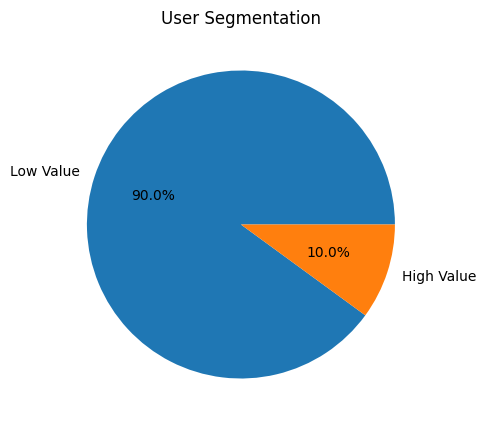

In [93]:
segment_counts = user_revenue['User_Type'].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%'
)

plt.title('User Segmentation')

plt.show()

In [94]:
event_revenue = df.groupby('Event').agg({
    'Revenue': 'sum',
    'User ID': 'nunique'
}).reset_index()

event_revenue.columns = ['Event', 'Revenue', 'Users']

event_revenue['Revenue_per_User'] = (
    event_revenue['Revenue'] / event_revenue['Users']
)

event_revenue

,Event,Revenue,Users,Revenue_per_User
0,Add to Cart,0.00,6949,0.000000
1,Browse,0.00,10000,0.000000
2,Checkout,0.00,3456,0.000000
3,Purchase,277323.06,1004,276.218187


In [95]:
event_revenue.sort_values(
    by='Revenue',
    ascending=False
)

,Event,Revenue,Users,Revenue_per_User
3,Purchase,277323.06,1004,276.218187
0,Add to Cart,0.00,6949,0.000000
1,Browse,0.00,10000,0.000000
2,Checkout,0.00,3456,0.000000


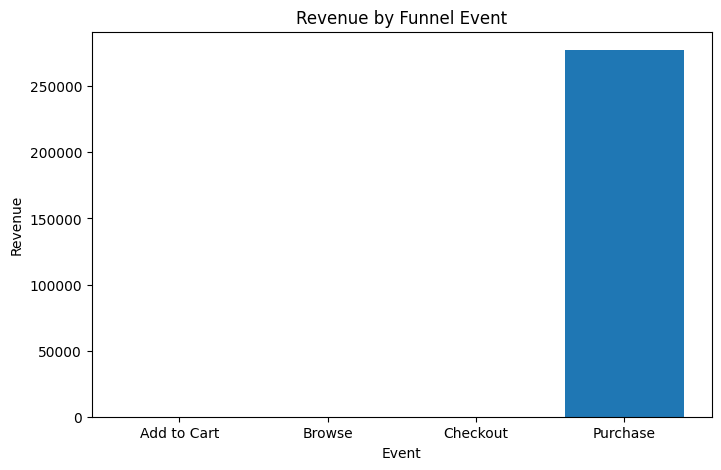

In [96]:
plt.figure(figsize=(8,5))

plt.bar(
    event_revenue['Event'],
    event_revenue['Revenue']
)

plt.xlabel('Event')
plt.ylabel('Revenue')
plt.title('Revenue by Funnel Event')

plt.show()

In [97]:
bonus_analysis = df.groupby('Bonus Flag').agg({
    'Revenue': 'sum',
    'User ID': 'nunique'
}).reset_index()

bonus_analysis.columns = ['Bonus_Flag', 'Revenue', 'Users']

bonus_analysis['Revenue_per_User'] = (
    bonus_analysis['Revenue'] / bonus_analysis['Users']
)

bonus_analysis

,Bonus_Flag,Revenue,Users,Revenue_per_User
0,No,277323.06,1004,276.218187
1,Yes,0.00,10000,0.000000


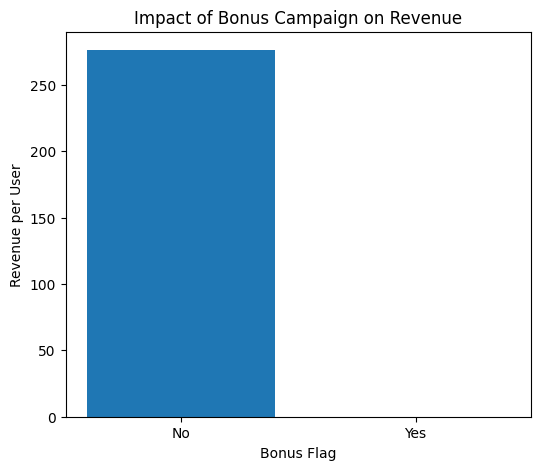

In [98]:
plt.figure(figsize=(6,5))

plt.bar(
    bonus_analysis['Bonus_Flag'].astype(str),
    bonus_analysis['Revenue_per_User']
)

plt.xlabel('Bonus Flag')
plt.ylabel('Revenue per User')
plt.title('Impact of Bonus Campaign on Revenue')

plt.show()

In [99]:
category_analysis = df.groupby('Product Category').agg({
    'Revenue': 'sum',
    'User ID': 'nunique'
}).reset_index()

category_analysis.columns = [
    'Product_Category',
    'Revenue',
    'Users'
]

category_analysis['Revenue_per_User'] = (
    category_analysis['Revenue'] / category_analysis['Users']
)

category_analysis.sort_values(
    by='Revenue',
    ascending=False
)

,Product_Category,Revenue,Users,Revenue_per_User
1,Electronics,62938.46,2052,30.671764
2,Fashion,58075.22,2001,29.023098
4,Sports,55856.01,1948,28.673516
0,Beauty,50353.36,2021,24.915072
3,Home,50100.01,1978,25.328620


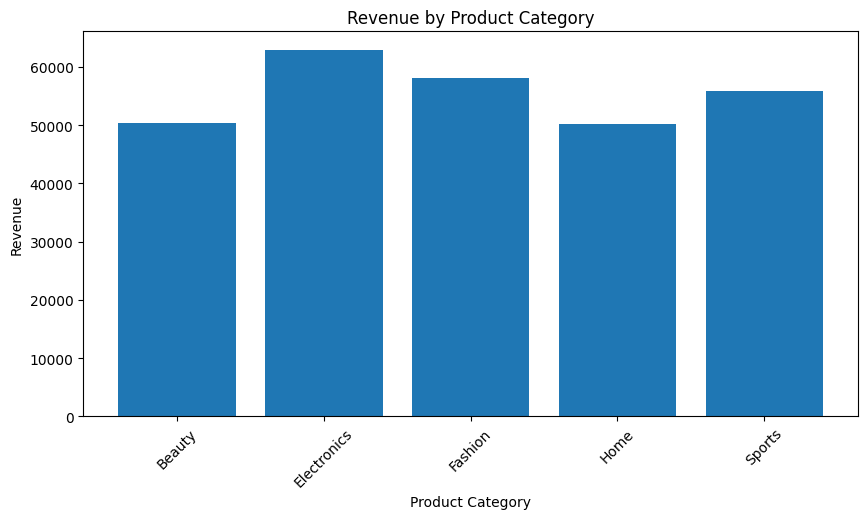

In [100]:
plt.figure(figsize=(10,5))

plt.bar(
    category_analysis['Product_Category'],
    category_analysis['Revenue']
)

plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.title('Revenue by Product Category')

plt.xticks(rotation=45)

plt.show()

In [101]:
import sqlite3

In [102]:
conn = sqlite3.connect('../sql/saas_funnel.db')

In [103]:
df.to_sql(
    'funnel_data',
    conn,
    if_exists='replace',
    index=False
)

21409

In [104]:
query = """
SELECT 
    Event,
    COUNT(DISTINCT `User ID`) AS users
FROM funnel_data
GROUP BY Event
"""

pd.read_sql(query, conn)

,Event,users
0,Add to Cart,6949
1,Browse,10000
2,Checkout,3456
3,Purchase,1004


In [105]:
query = """
SELECT
    Channel,
    ROUND(SUM(Revenue),2) AS total_revenue,
    COUNT(DISTINCT `User ID`) AS total_users,
    ROUND(
        SUM(Revenue) * 1.0 /
        COUNT(DISTINCT `User ID`),
        2
    ) AS revenue_per_user
FROM funnel_data
GROUP BY Channel
ORDER BY revenue_per_user DESC
"""

pd.read_sql(query, conn)

,Channel,total_revenue,total_users,revenue_per_user
0,Google Ads,73862.32,2520,29.31
1,Social Media,68361.24,2437,28.05
2,Email,69126.46,2515,27.49
3,Organic,65973.04,2528,26.10


In [106]:
query = """
SELECT
    Device,
    ROUND(SUM(Revenue),2) AS revenue,
    COUNT(DISTINCT `User ID`) AS users,
    ROUND(
        SUM(Revenue) * 1.0 /
        COUNT(DISTINCT `User ID`),
        2
    ) AS revenue_per_user
FROM funnel_data
GROUP BY Device
ORDER BY revenue_per_user DESC
"""

pd.read_sql(query, conn)

,Device,revenue,users,revenue_per_user
0,Desktop,98471.83,3366,29.25
1,Tablet,94620.13,3371,28.07
2,Mobile,84231.10,3263,25.81


In [107]:
query = """
SELECT
    Event,
    COUNT(DISTINCT `User ID`) AS users
FROM funnel_data
GROUP BY Event
ORDER BY users DESC
"""

pd.read_sql(query, conn)

,Event,users
0,Browse,10000
1,Add to Cart,6949
2,Checkout,3456
3,Purchase,1004


In [108]:
query = """
SELECT
    Region,
    ROUND(SUM(Revenue),2) AS total_revenue,
    COUNT(DISTINCT `User ID`) AS total_users,
    ROUND(
        SUM(Revenue) * 1.0 /
        COUNT(DISTINCT `User ID`),
        2
    ) AS revenue_per_user
FROM funnel_data
GROUP BY Region
ORDER BY total_revenue DESC
"""

pd.read_sql(query, conn)

,Region,total_revenue,total_users,revenue_per_user
0,South,77421.45,2543,30.44
1,North,68645.13,2463,27.87
2,East,66116.01,2548,25.95
3,West,65140.47,2446,26.63


In [109]:
df.to_csv('../dashboard/clean_funnel_data.csv', index=False)